### Importing libraries

In [ ]:
#Import usefull tools
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score , recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from safeaipackage import core, check_explainability, check_fairness, check_robustness
import warnings
warnings.filterwarnings("ignore")

### Features Engineering 

In [15]:
#Load the dataset
df = pd.read_csv('dataset_1_lendingclub.csv')

#Add some columns to the dataset 
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
df["credit_age"] = 2024 - df["earliest_cr_line"].dt.year
df["credit_usage_ratio"] = df["revol_bal"] / (df["total_rev_hi_lim"] + 1)
df["has_record"] = (df["mths_since_last_record"] < 120).astype(int)
df["public_record_score"] = df["pub_rec_bankruptcies"] + df["tax_liens"]
df["credit_recent_activity_score"] = df["acc_open_past_24mths"] + df["num_tl_op_past_12m"]
df["loan_to_income_ratio"] = df["loan_amnt"] / (df["annual_inc"] + 1)
df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

#Show the key elements of the dataset
print(df.shape)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(df.head())
print(df.columns.tolist())

(2260701, 158)
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade                    emp_title  \
0     13.99       123.03     C        C4                      leadman   
1     11.99       820.28     C        C1                     Engineer   
2     10.78       432.66     B        B4                 truck driver   
3     14.85       829.90     C        C5  Information Systems Officer   
4     22.45       289.91     F        F1          Contract Specialist   

  emp_length home_ownership  annual_inc verification_status   issue_d  

### Data Exploring and Preprocessing

In [17]:
#Trasform the loan_status in a numerical variable
#Delete 'Current' in the column 'loan_status'
keep_status = ['Fully Paid', 'Charged Off']
df_numerical = df[df['loan_status'].isin(keep_status)].copy()

#Assign numerical values to the categorical variables contained in 'loan_status'
mapping = {'Fully Paid': 0,'Charged Off': 1}
df_numerical['loan_status'] = df_numerical['loan_status'].map(mapping)

#Check the change
print(df_numerical['loan_status'].value_counts())
print(df_numerical['loan_status'].value_counts().sum())
print(df_numerical['loan_status'].dtypes)
print(df_numerical.shape)

loan_status
0    1076751
1     268559
Name: count, dtype: int64
1345310
int64
(1345310, 158)


In [19]:
#Correlation detection 
#Correlation with 'loan_status'
corr_matrix = df_numerical.corr(numeric_only=True)
loan_status_corr = corr_matrix[['loan_status']].sort_values(by='loan_status', ascending=False)
strong_corr = loan_status_corr[(loan_status_corr['loan_status'] > 0.3) |
                              (loan_status_corr['loan_status'] < -0.4)]

print("Strong correlations (|r| > 0.3) with loan_status:")
print(strong_corr)

Strong correlations (r > 0.3) with loan_status:
                         loan_status
loan_status                 1.000000
recoveries                  0.505415
collection_recovery_fee     0.480216
total_rec_prncp            -0.438944
last_fico_range_low        -0.575706
last_fico_range_high       -0.667842


In [21]:
#Define the columns that I want that stay in the dataset
desired_cols = desired_cols = [
    'annual_inc','dti','int_rate','installment','grade','loan_amnt','loan_status',
    'open_acc','pub_rec','delinq_2yrs','inq_last_6mths','fico_range_low',
    'fico_range_high', 'total_acc', 'home_ownership',
    'credit_age','credit_usage_ratio','has_record','public_record_score',
    'credit_recent_activity_score', 'loan_to_income_ratio', 'fico_avg','addr_state']

#Define a new dataset which contains only the selected columns
df_filtered = df_numerical.copy()
existing = [c for c in desired_cols if c in df.columns]
df_filtered = df_numerical[existing].copy()

#Check the new dataset
print("Colomns of df_filtered:", df_filtered.columns.tolist())
print(df_filtered.shape)
print(df_filtered.dtypes)
print(df_filtered.head())

#Check that the two dataset are effectively different
print(df_filtered.shape, df_numerical.shape)

Colomns of df_filtered: ['annual_inc', 'dti', 'int_rate', 'installment', 'grade', 'loan_amnt', 'loan_status', 'open_acc', 'pub_rec', 'delinq_2yrs', 'inq_last_6mths', 'fico_range_low', 'fico_range_high', 'total_acc', 'home_ownership', 'credit_age', 'credit_usage_ratio', 'has_record', 'public_record_score', 'credit_recent_activity_score', 'loan_to_income_ratio', 'fico_avg', 'addr_state']
(1345310, 23)
annual_inc                      float64
dti                             float64
int_rate                        float64
installment                     float64
grade                            object
loan_amnt                       float64
loan_status                       int64
open_acc                        float64
pub_rec                         float64
delinq_2yrs                     float64
inq_last_6mths                  float64
fico_range_low                  float64
fico_range_high                 float64
total_acc                       float64
home_ownership                   obje

In [23]:
#Drop the duplicates
print("Dataset filtered with duplicates:", df_filtered.shape)
df_filtered = df_filtered.drop_duplicates()
print("Dataset filtered without duplicates", df_filtered.shape)

Dataset filtered with duplicates: (1345310, 23)
Dataset filtered without duplicates (1345309, 23)


In [25]:
#Show the categorical columns
print('Information about column grade \n')
print(df_filtered["grade"].value_counts())
print(df_filtered["grade"].value_counts().sum())
print('Information about column home_ownership \n')
print(df_filtered["home_ownership"].value_counts())
print(df_filtered["home_ownership"].value_counts().sum())
print('Information about column addr_state \n')
print(df_filtered["addr_state"].value_counts())
print(df_filtered["addr_state"].value_counts().sum())

Information about column grade 

grade
B    392740
C    381686
A    235090
D    200953
E     93650
F     32058
G      9132
Name: count, dtype: int64
1345309
Information about column home_ownership 

home_ownership
MORTGAGE    665579
RENT        534421
OWN         144831
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64
1345309
Information about column addr_state 

addr_state
CA    196528
TX    110169
NY    109842
FL     95606
IL     51720
NJ     48449
PA     45522
OH     43842
GA     43376
VA     38040
NC     37784
MI     35234
AZ     32695
MD     31227
MA     30976
CO     29671
WA     29188
MN     23968
IN     21716
MO     21260
TN     20385
NV     20267
CT     19728
WI     17732
AL     16613
OR     16406
SC     15992
LA     15499
KY     12839
OK     12281
KS     11240
AR     10047
UT     10036
NM      7362
HI      6757
MS      6588
NH      6449
RI      5871
WV      4878
MT      3823
DE      3783
NE      3586
DC      3475
AK      3190
WY      2922
SD  

In [27]:
#Mapping the grade variable
df_filtered['grade'] = df_filtered['grade'].str.strip().str.upper()
mapping_grade = {'A':6,'B':5,'C':4,'D':3,'E':2,'F':1, 'G':0}
df_filtered['grade'] = df_filtered['grade'].map(mapping_grade)

#Check if the values are deleted
print(df_filtered['grade'].value_counts())
print(df_filtered['grade'].value_counts().sum())
print(df_filtered['grade'].dtypes)

#Dataset all in numerical variable
print(df_filtered.head())
print(df_filtered.dtypes)

grade
5    392740
4    381686
6    235090
3    200953
2     93650
1     32058
0      9132
Name: count, dtype: int64
1345309
int64
   annual_inc    dti  int_rate  installment  grade  loan_amnt  loan_status  \
0     55000.0   5.91     13.99       123.03      4     3600.0            0   
1     65000.0  16.06     11.99       820.28      4    24700.0            0   
2     63000.0  10.78     10.78       432.66      5    20000.0            0   
4    104433.0  25.37     22.45       289.91      1    10400.0            0   
5     34000.0  10.20     13.44       405.18      4    11950.0            0   

   open_acc  pub_rec  delinq_2yrs  inq_last_6mths  fico_range_low  \
0       7.0      0.0          0.0             1.0           675.0   
1      22.0      0.0          1.0             4.0           715.0   
2       6.0      0.0          0.0             0.0           695.0   
4      12.0      0.0          1.0             3.0           695.0   
5       5.0      0.0          0.0             0.0       

In [29]:
#Find states to include in nord area
nord = [
    'CT', 'DE', 'IA', 'ID', 'IL', 'IN', 'MA', 'ME', 'MI', 'MN',
    'MT', 'ND', 'NE', 'NH', 'NJ', 'NY', 'OH', 'OR', 'PA', 'RI',
    'SD', 'VT', 'WA', 'WI', 'WY'
]

df_filtered['addr_state'] = df['addr_state'].apply(lambda x: 0 if x in nord else 1)
print(df_filtered["addr_state"].value_counts())
print(df_filtered["addr_state"].value_counts().sum())

addr_state
1    813805
0    531504
Name: count, dtype: int64
1345309


In [31]:
#Trasform home_ownership
df_filtered['home_ownership'] = df_filtered['home_ownership'].str.strip().str.upper()


In [33]:
df_filtered = pd.get_dummies(df_filtered, columns=['home_ownership'], drop_first=False)

#Trasform home_ownership dummy columns in binaty columns from bool values
df_filtered['home_ownership_MORTGAGE'] = df_filtered['home_ownership_MORTGAGE'].astype(int)
df_filtered['home_ownership_RENT'] = df_filtered['home_ownership_RENT'].astype(int)
df_filtered['home_ownership_OWN'] = df_filtered['home_ownership_OWN'].astype(int)
df_filtered['home_ownership_ANY'] = df_filtered['home_ownership_ANY'].astype(int)
df_filtered['home_ownership_OTHER'] = df_filtered['home_ownership_OTHER'].astype(int)
df_filtered['home_ownership_NONE'] = df_filtered['home_ownership_NONE'].astype(int)

#Check the results
print(df_filtered.head())
print(df_filtered.dtypes)

   annual_inc    dti  int_rate  installment  grade  loan_amnt  loan_status  \
0     55000.0   5.91     13.99       123.03      4     3600.0            0   
1     65000.0  16.06     11.99       820.28      4    24700.0            0   
2     63000.0  10.78     10.78       432.66      5    20000.0            0   
4    104433.0  25.37     22.45       289.91      1    10400.0            0   
5     34000.0  10.20     13.44       405.18      4    11950.0            0   

   open_acc  pub_rec  delinq_2yrs  inq_last_6mths  fico_range_low  \
0       7.0      0.0          0.0             1.0           675.0   
1      22.0      0.0          1.0             4.0           715.0   
2       6.0      0.0          0.0             0.0           695.0   
4      12.0      0.0          1.0             3.0           695.0   
5       5.0      0.0          0.0             0.0           690.0   

   fico_range_high  total_acc  credit_age  credit_usage_ratio  has_record  \
0            679.0       13.0        21

In [35]:
#Missing values detecting
print(df_filtered.info())
print('Null values in the dataset: \n')
print(df_filtered.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1345309 entries, 0 to 2260697
Data columns (total 28 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   annual_inc                    1345309 non-null  float64
 1   dti                           1344935 non-null  float64
 2   int_rate                      1345309 non-null  float64
 3   installment                   1345309 non-null  float64
 4   grade                         1345309 non-null  int64  
 5   loan_amnt                     1345309 non-null  float64
 6   loan_status                   1345309 non-null  int64  
 7   open_acc                      1345309 non-null  float64
 8   pub_rec                       1345309 non-null  float64
 9   delinq_2yrs                   1345309 non-null  float64
 10  inq_last_6mths                1345308 non-null  float64
 11  fico_range_low                1345309 non-null  float64
 12  fico_range_high               134

In [37]:
#Percentage of missing values
print('Percentage of null values in review columns: ')
print("dti:",round(df_filtered['dti'].isnull().sum()/len(df_filtered)*100, 7),"%")
print("inq_last_6mths:",round(df_filtered['inq_last_6mths'].isnull().sum()/len(df_filtered)*100, 7),"%")
print("credit_usage ratio:",round(df_filtered['credit_usage_ratio'].isnull().sum()/len(df_filtered)*100, 7),"%")
print("public_record_score:",round(df_filtered['public_record_score'].isnull().sum()/len(df_filtered)*100, 7),"%")
print("credit_recent_activity_score:",round(df_filtered['credit_recent_activity_score'].isnull().sum()/len(df_filtered)*100, 7),"%")

Percentage of null values in review columns: 
dti: 0.0278003 %
inq_last_6mths: 7.43e-05 %
credit_usage ratio: 5.0193673 %
public_record_score: 0.0518097 %
credit_recent_activity_score: 5.0193673 %


In [47]:
#Fill missing values for inq_last_6mths
df_final = df_filtered.copy()
df_final['inq_last_6mths'] = df_final['inq_last_6mths'].fillna(value=0, inplace=False)
print(df_final.shape, '\n')
print('Null values in the dataset: \n')
print(df_final.isna().sum())

(1345309, 28) 

Null values in the dataset: 

annual_inc                          0
dti                               374
int_rate                            0
installment                         0
grade                               0
loan_amnt                           0
loan_status                         0
open_acc                            0
pub_rec                             0
delinq_2yrs                         0
inq_last_6mths                      0
fico_range_low                      0
fico_range_high                     0
total_acc                           0
credit_age                          0
credit_usage_ratio              67526
has_record                          0
public_record_score               697
credit_recent_activity_score    67526
loan_to_income_ratio                0
fico_avg                            0
addr_state                          0
home_ownership_ANY                  0
home_ownership_MORTGAGE             0
home_ownership_NONE                 0
home

In [49]:
#Fill missing values for public_record_score
df_final['public_record_score'] = df_final['public_record_score'].fillna(value=0, inplace=False)
print(df_final.shape, '\n')
print('Null values in the dataset: \n')
print(df_final.isna().sum())

(1345309, 28) 

Null values in the dataset: 

annual_inc                          0
dti                               374
int_rate                            0
installment                         0
grade                               0
loan_amnt                           0
loan_status                         0
open_acc                            0
pub_rec                             0
delinq_2yrs                         0
inq_last_6mths                      0
fico_range_low                      0
fico_range_high                     0
total_acc                           0
credit_age                          0
credit_usage_ratio              67526
has_record                          0
public_record_score                 0
credit_recent_activity_score    67526
loan_to_income_ratio                0
fico_avg                            0
addr_state                          0
home_ownership_ANY                  0
home_ownership_MORTGAGE             0
home_ownership_NONE                 0
home

In [51]:
#Fill Missing values in 'dti' extimating that number with installment (=payment per month)/(annual_inc/12)
#I can do also a better extimation with a regression model
df_final['dti_extimated'] = df_final['installment'] / (df_final['annual_inc'] / 12)
df_final['dti'].fillna(df_final['dti_extimated'], inplace=True)
df_final.drop(columns='dti_extimated', inplace=True)
print(df_final.shape, '\n')
print('Null values in the dataset: \n')
print(df_final.isna().sum())

(1345309, 28) 

Null values in the dataset: 

annual_inc                          0
dti                                 0
int_rate                            0
installment                         0
grade                               0
loan_amnt                           0
loan_status                         0
open_acc                            0
pub_rec                             0
delinq_2yrs                         0
inq_last_6mths                      0
fico_range_low                      0
fico_range_high                     0
total_acc                           0
credit_age                          0
credit_usage_ratio              67526
has_record                          0
public_record_score                 0
credit_recent_activity_score    67526
loan_to_income_ratio                0
fico_avg                            0
addr_state                          0
home_ownership_ANY                  0
home_ownership_MORTGAGE             0
home_ownership_NONE                 0
home

In [53]:
#Drop the created columns in which there are missing values
df_final = df_final.drop(columns=['credit_usage_ratio', 'credit_recent_activity_score'])
print(df_final.shape)

(1345309, 26)


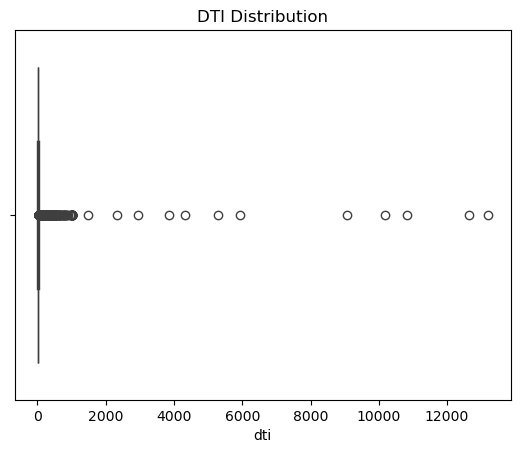

The maximun value in the column is: inf


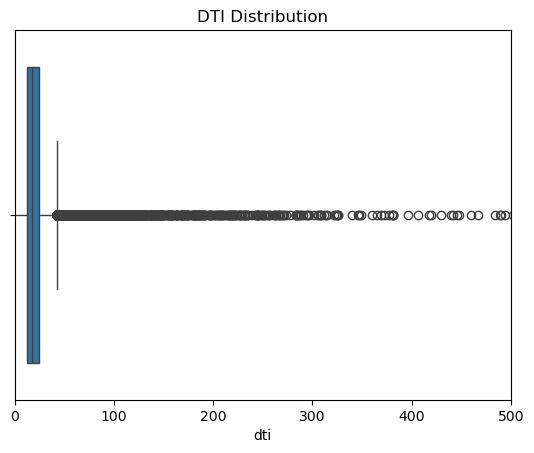

In [55]:
#Study the 'dti' (debt-to-income ratio)
#Boxplot of 'dti' (debt-to-income ratio)
sns.boxplot(x=df_final['dti'])
plt.title("DTI Distribution")
plt.show()

#Boxplot of 'dti' (debt-to-income ratio) with limits
print('The maximun value in the column is:', df_final['dti'].max())
sns.boxplot(x=df_final['dti'])
plt.title("DTI Distribution")
plt.xlim(0, 500)
plt.show()

In [57]:
#Try to discover why the maximum value of the ratio is 'inf'
print('Number of dti items that goes to infinity:', sum(1 for i in df_final['dti'] if i > 10000000000))
print('Number of annual_inc items equal to zero', sum(1 for i in df_final['annual_inc'] if i == 0))

Number of dti items that goes to infinity: 361
Number of annual_inc items equal to zero 361


In [59]:
#Correlation with 'annual_income'
corr_matrix = df_numerical.corr(numeric_only=True)
loan_status_corr = corr_matrix[['annual_inc']].sort_values(by='annual_inc', ascending=False)
strong_corr = loan_status_corr[(loan_status_corr['annual_inc'] > 0.3) |
                              (loan_status_corr['annual_inc'] < -0.4)]
print("Strong correlations (|r| > 0.3) with annual_inc:")
print(strong_corr)

Strong correlations (|r| > 0.3) with annual_inc:
                                annual_inc
annual_inc                        1.000000
annual_inc_joint                  0.691575
tot_hi_cred_lim                   0.411350
tot_cur_bal                       0.398275
hardship_payoff_balance_amount    0.387074
total_bal_ex_mort                 0.316942
loan_amnt                         0.311794
funded_amnt                       0.311701
funded_amnt_inv                   0.311398
avg_cur_bal                       0.307911
revol_bal_joint                   0.304244
installment                       0.302499


In [61]:
#Check if in the columns annual_inc_joint, tot_hi_cred_lim and tot_cur_bal there are values equal to zero
print('Number of annual_inc_joint items equal to zero', sum(1 for i in df['annual_inc_joint'] if i == 0))
print('Number of tot_hi_cred_lim items equal to zero', sum(1 for i in df['tot_hi_cred_lim'] if i == 0))
print('Number of tot_cur_bal items equal to zero', sum(1 for i in df['tot_cur_bal'] if i == 0))

#Missing values detecting
#print(df.info())
print('Null values in the dataset: \n')
print(df.isnull().sum())

Number of annual_inc_joint items equal to zero 0
Number of tot_hi_cred_lim items equal to zero 70
Number of tot_cur_bal items equal to zero 959
Null values in the dataset: 

id                                                  0
member_id                                     2260701
loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
term                                               33
int_rate                                           33
installment                                        33
grade                                              33
sub_grade                                          33
emp_title                                      167002
emp_length                                     146940
home_ownership                                     33
annual_inc                                         37
verification_status                                33
issue_d         

Text(0.5, 1.0, 'Heat Map')

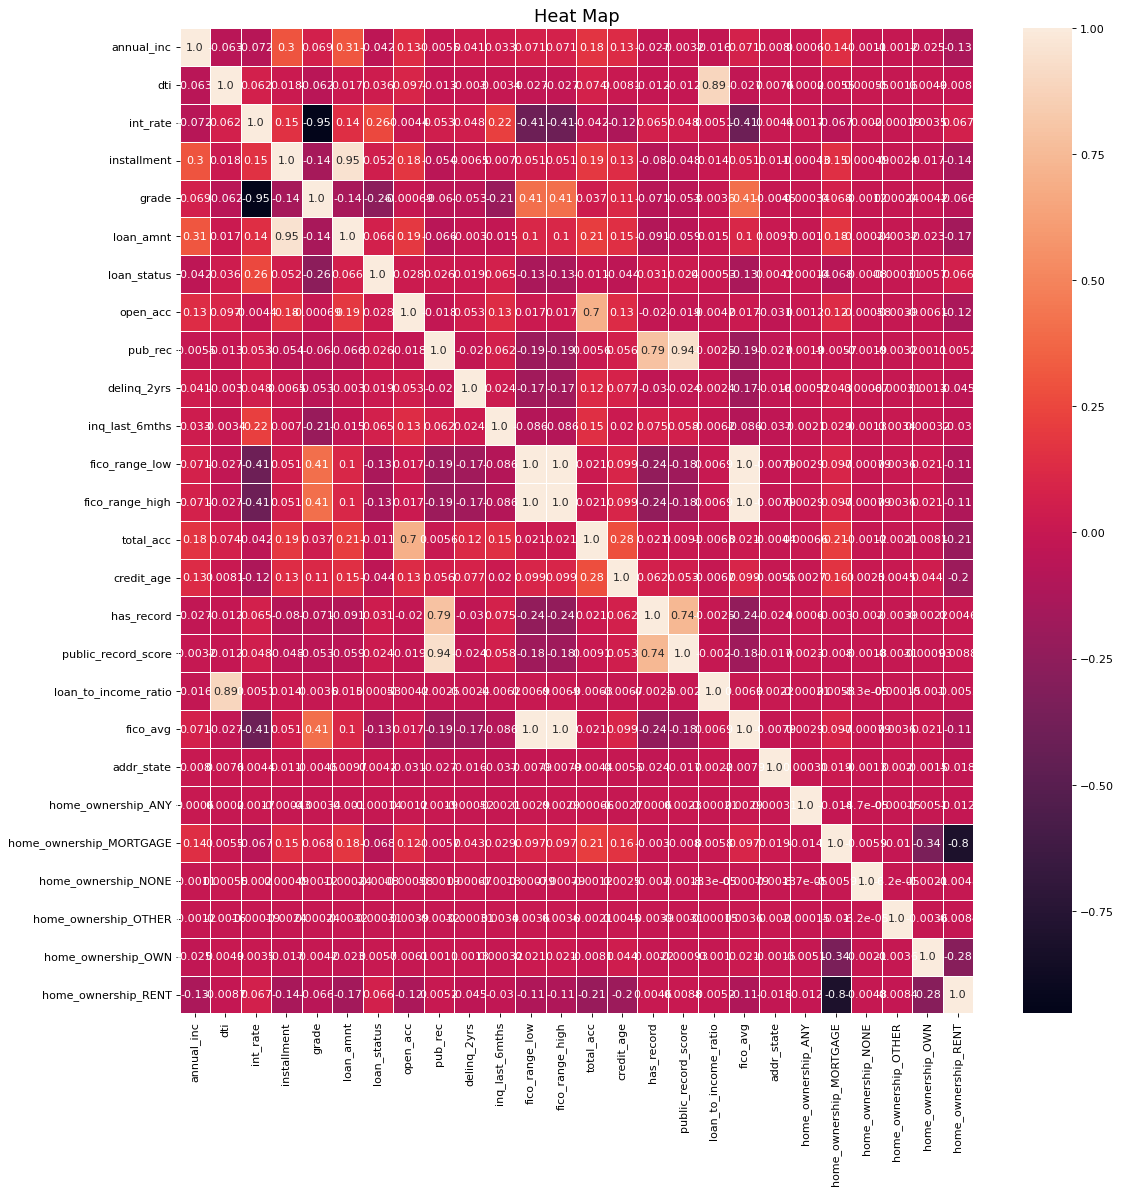

In [65]:
#Heat map to discover the regressors that are usefull to extimate 'annual_inc' (annual income)
#Represent the correlation between the numerical variables thougth The heat map
corr = df_final.corr(numeric_only= True)
plt.figure(figsize=(16,16), dpi= 80)
sns.heatmap(corr, annot=True , fmt=".2" ,linewidths=.9)
plt.title('Heat Map', fontsize=16)

In [67]:
#There are to much missing values in the columns with high correlation with annual_inc then 
#I will use a random forest for continuous response variable to extimate the annual_inc
df_final_annual_inc = df_final.drop(columns = ['dti','int_rate','installment','grade','loan_status']).copy()

#Drop outliers
cols = ['annual_inc','loan_amnt','open_acc','total_acc'] 
mask = pd.Series(True, index=df.index)

for col in cols:
    Q1 = df_final_annual_inc[col].quantile(0.25)
    Q3 = df_final_annual_inc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= df_final_annual_inc[col].between(lower_bound, upper_bound)
df_final_annual_inc_no_outliers = df_final_annual_inc[mask]
print(df_final_annual_inc_no_outliers.shape)

(1222692, 21)


In [69]:
#Scaling the dataset
mm_scaler = preprocessing.MinMaxScaler()
df_final_annual_inc_scaled = pd.DataFrame(mm_scaler.fit_transform(df_final_annual_inc_no_outliers),columns = df_final_annual_inc_no_outliers.columns)

In [71]:
#Split the dataset in train and test
X = df_final_annual_inc_scaled.drop("annual_inc", axis = 1)
y = df_final_annual_inc_scaled["annual_inc"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [73]:
#Train and predict with the RandomForestRegressor
model_annual_inc = RandomForestRegressor(n_estimators=20,max_depth=10,n_jobs=-1,random_state=42)
model_annual_inc.fit(X_train, y_train)
y_pred = model_annual_inc.predict(X_test)

In [77]:
#Check the performance of the model
mse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")

MSE: 0.15
R^2: 0.35


In [79]:
#The only solution is drop the dti values that are missing from the dataset due to the impossibility to extimate the annual_inc

#Fill missing values for inq_last_6mths
df_final2 = df_filtered.copy()
df_final2['inq_last_6mths'] = df_final2['inq_last_6mths'].fillna(value=0, inplace=False)
print(df_final2.shape, '\n')
print('Null values in the dataset: \n')
print(df_final2.isna().sum())

#Fill missing values for public_record_score
df_final2['public_record_score'] = df_final2['public_record_score'].fillna(value=0, inplace=False)
print(df_final.shape, '\n')
print('Null values in the dataset: \n')
print(df_final.isna().sum())

#Drop 'dti' missing values
df_final2 = df_final2.dropna(subset=['dti'])
print(df_final2.shape, '\n')
print('Null values in the dataset: \n')
print(df_final2.isna().sum())

#Drop the created columns in which there are missing values
df_final2 = df_final2.drop(columns=['credit_usage_ratio','credit_recent_activity_score'])
print(df_final2.shape)


(1345309, 28) 

Null values in the dataset: 

annual_inc                          0
dti                               374
int_rate                            0
installment                         0
grade                               0
loan_amnt                           0
loan_status                         0
open_acc                            0
pub_rec                             0
delinq_2yrs                         0
inq_last_6mths                      0
fico_range_low                      0
fico_range_high                     0
total_acc                           0
credit_age                          0
credit_usage_ratio              67526
has_record                          0
public_record_score               697
credit_recent_activity_score    67526
loan_to_income_ratio                0
fico_avg                            0
addr_state                          0
home_ownership_ANY                  0
home_ownership_MORTGAGE             0
home_ownership_NONE                 0
home

The maximun value in the column is: 999.0


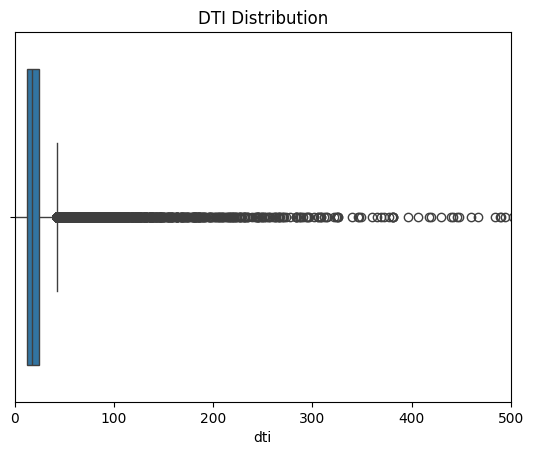

The maximun value in the column is: 10999200.0


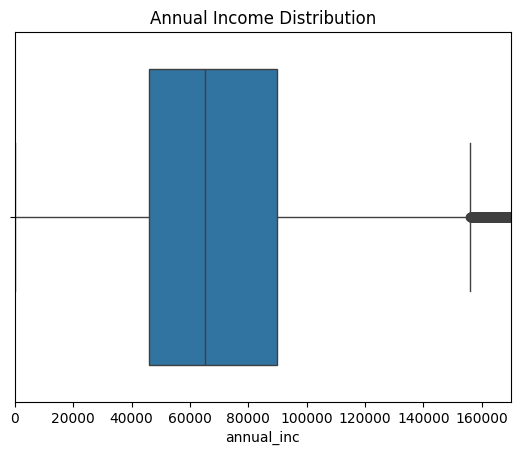

The maximun value in the column is: 30.99


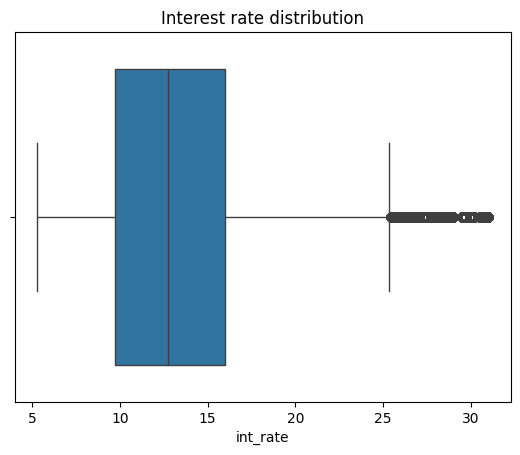

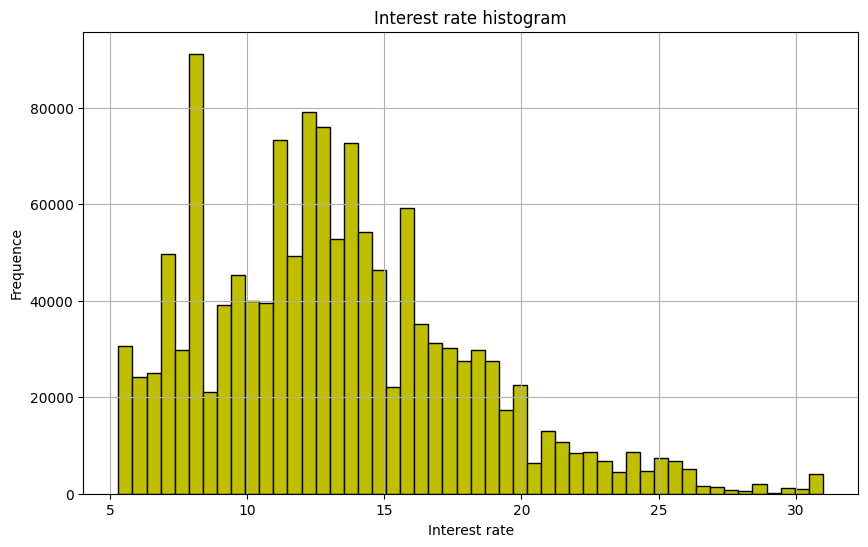

In [29]:
#Perform again the analysis on 'dti'
#Boxplot of 'dti' (debt-to-income ratio) with limits
print('The maximun value in the column is:', df_final2['dti'].max())
sns.boxplot(x=df_final2['dti'])
plt.title("DTI Distribution")
plt.xlim(0, 500)
plt.show()

#Boxplot of 'annual_inc' (annual income) with limits
print('The maximun value in the column is:', df_final2['annual_inc'].max())
sns.boxplot(x=df_final2['annual_inc'])
plt.title("Annual Income Distribution")
plt.xlim(0, 170000)
plt.show()

#Boxplot of 'int_rate' (interest rate)
print('The maximun value in the column is:', df_final2['int_rate'].max())
sns.boxplot(x=df_final2['int_rate'])
plt.title("Interest rate distribution")
plt.show()

#Histogram of 'int_rate' (interest rate)
df_final2['int_rate'].hist(bins=50, edgecolor='black', color = 'y', figsize=(10,6))
plt.xlabel('Interest rate')
plt.ylabel('Frequence')
plt.title('Interest rate histogram')
plt.show()

In [81]:
#Drop outliers using boxplots
cols = ['annual_inc','dti','int_rate']
mask = pd.Series(True, index=df.index)

for col in cols:
    Q1 = df_final2[col].quantile(0.25)
    Q3 = df_final2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= df_final2[col].between(lower_bound, upper_bound)
df_final2_no_outliers1 = df_final2[mask]
df_final2_no_outliers = df_final2_no_outliers1[(df_final2_no_outliers1['dti'] < 1000) & (df_final2_no_outliers1['int_rate'] < 40)]
print(df_final2_no_outliers.shape)
print(df_final2_no_outliers.dtypes)
print(df_final2_no_outliers.isnull().sum())

(1250094, 26)
annual_inc                 float64
dti                        float64
int_rate                   float64
installment                float64
grade                        int64
loan_amnt                  float64
loan_status                  int64
open_acc                   float64
pub_rec                    float64
delinq_2yrs                float64
inq_last_6mths             float64
fico_range_low             float64
fico_range_high            float64
total_acc                  float64
credit_age                 float64
has_record                   int32
public_record_score        float64
loan_to_income_ratio       float64
fico_avg                   float64
addr_state                   int64
home_ownership_ANY           int32
home_ownership_MORTGAGE      int32
home_ownership_NONE          int32
home_ownership_OTHER         int32
home_ownership_OWN           int32
home_ownership_RENT          int32
dtype: object
annual_inc                 0
dti                        0
int_

<Axes: ylabel='int_rate'>

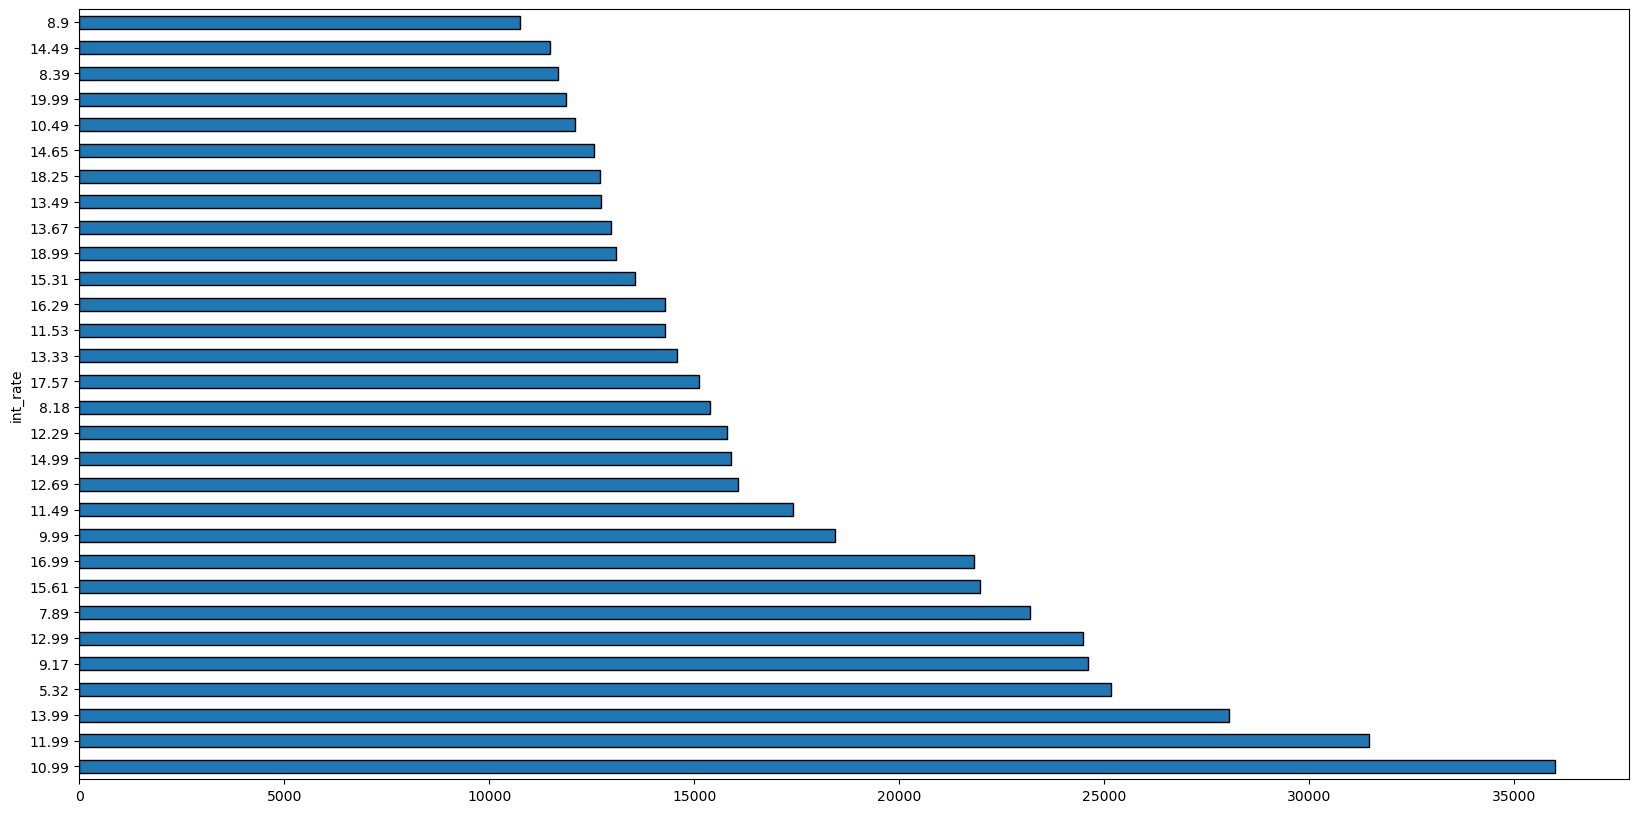

In [83]:
#Frequency of the most 30 common 'int_rate' (interest rate)
df_final2_no_outliers['int_rate'].value_counts().head(30).plot(kind='barh', edgecolor='black', figsize=(20,10))

<Axes: ylabel='fico_range_high'>

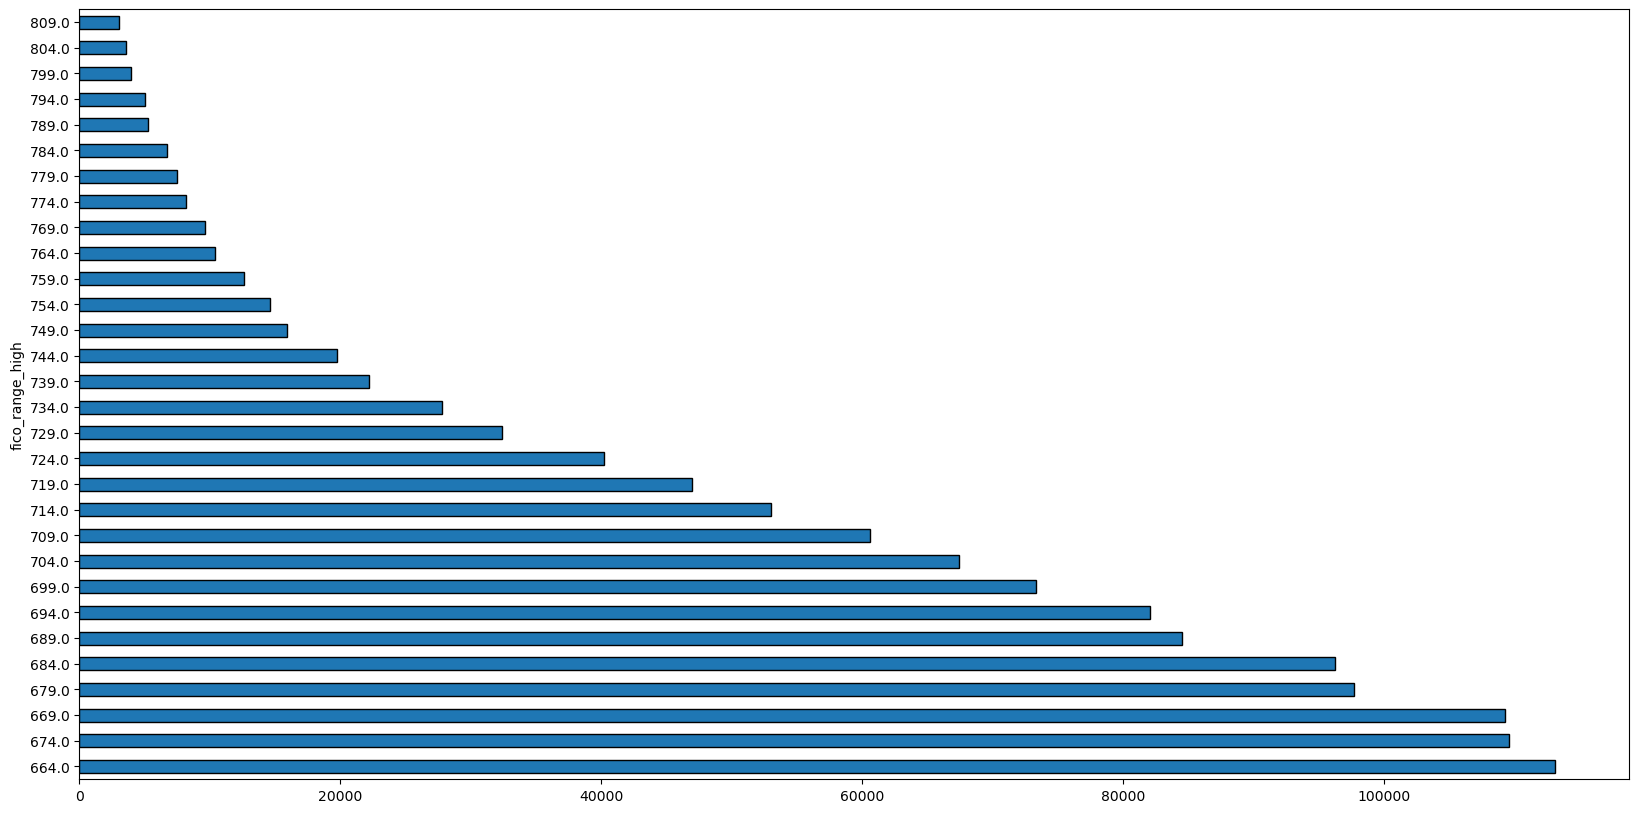

In [85]:
#Frequency of the most 30 common 'last_fico_range_high'
df_final2_no_outliers['fico_range_high'].value_counts().head(30).plot(kind='barh', edgecolor='black', figsize=(20,10))

<Axes: ylabel='fico_range_low'>

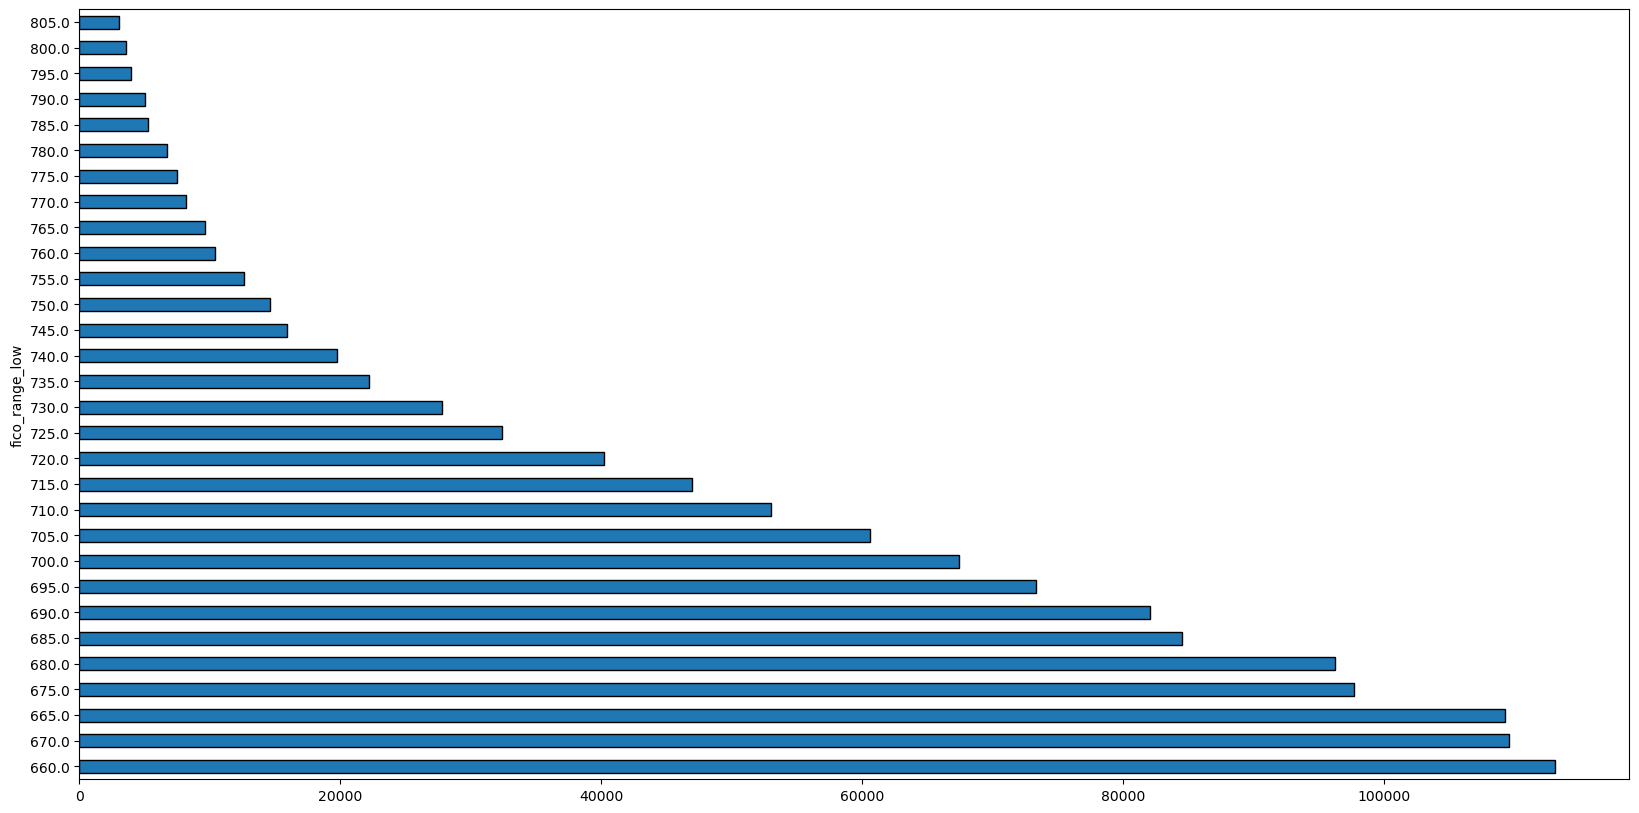

In [87]:
#Frequency of the most 30 common 'last_fico_range_low'
df_final2_no_outliers['fico_range_low'].value_counts().head(30).plot(kind='barh', edgecolor='black', figsize=(20,10))

In [89]:
#Detect the max value for each column
max_values = df_final2_no_outliers.max()
print('The maximum value for each column is:\n', max_values)

The maximum value for each column is:
 annual_inc                 156148.000000
dti                            42.460000
int_rate                       25.340000
installment                  1587.230000
grade                           6.000000
loan_amnt                   40000.000000
loan_status                     1.000000
open_acc                       90.000000
pub_rec                        86.000000
delinq_2yrs                    39.000000
inq_last_6mths                  8.000000
fico_range_low                845.000000
fico_range_high               850.000000
total_acc                     176.000000
credit_age                     90.000000
has_record                      1.000000
public_record_score            86.000000
loan_to_income_ratio           19.973369
fico_avg                      847.500000
addr_state                      1.000000
home_ownership_ANY              1.000000
home_ownership_MORTGAGE         1.000000
home_ownership_NONE             1.000000
home_ownership_OTH

loan_status
0    1004202
1     245892
Name: count, dtype: int64
object


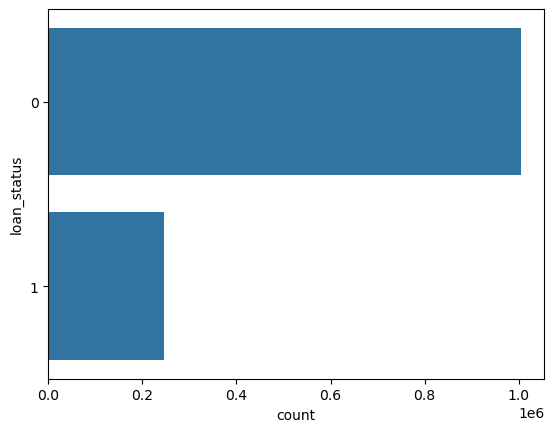

In [91]:
#Check the distribution of the response variable
print(df_final2_no_outliers["loan_status"].value_counts())
df_final2_no_outliers['loan_status'] = df_final2_no_outliers['loan_status'].astype(str).str.strip()
sns.countplot(df_final2_no_outliers["loan_status"])
print(df_final2_no_outliers["loan_status"].dtypes)

In [93]:
#Back loan_status an 'int' variable
print(df_final2_no_outliers["loan_status"].dtypes)
df_final2_no_outliers['loan_status'] = df_final2_no_outliers['loan_status'].astype(float)
df_final2_no_outliers['loan_status'] = df_final2_no_outliers['loan_status'].astype(int)
print(df_final2_no_outliers["loan_status"].dtypes)

object
int32


Text(0.5, 1.0, 'Heat Map')

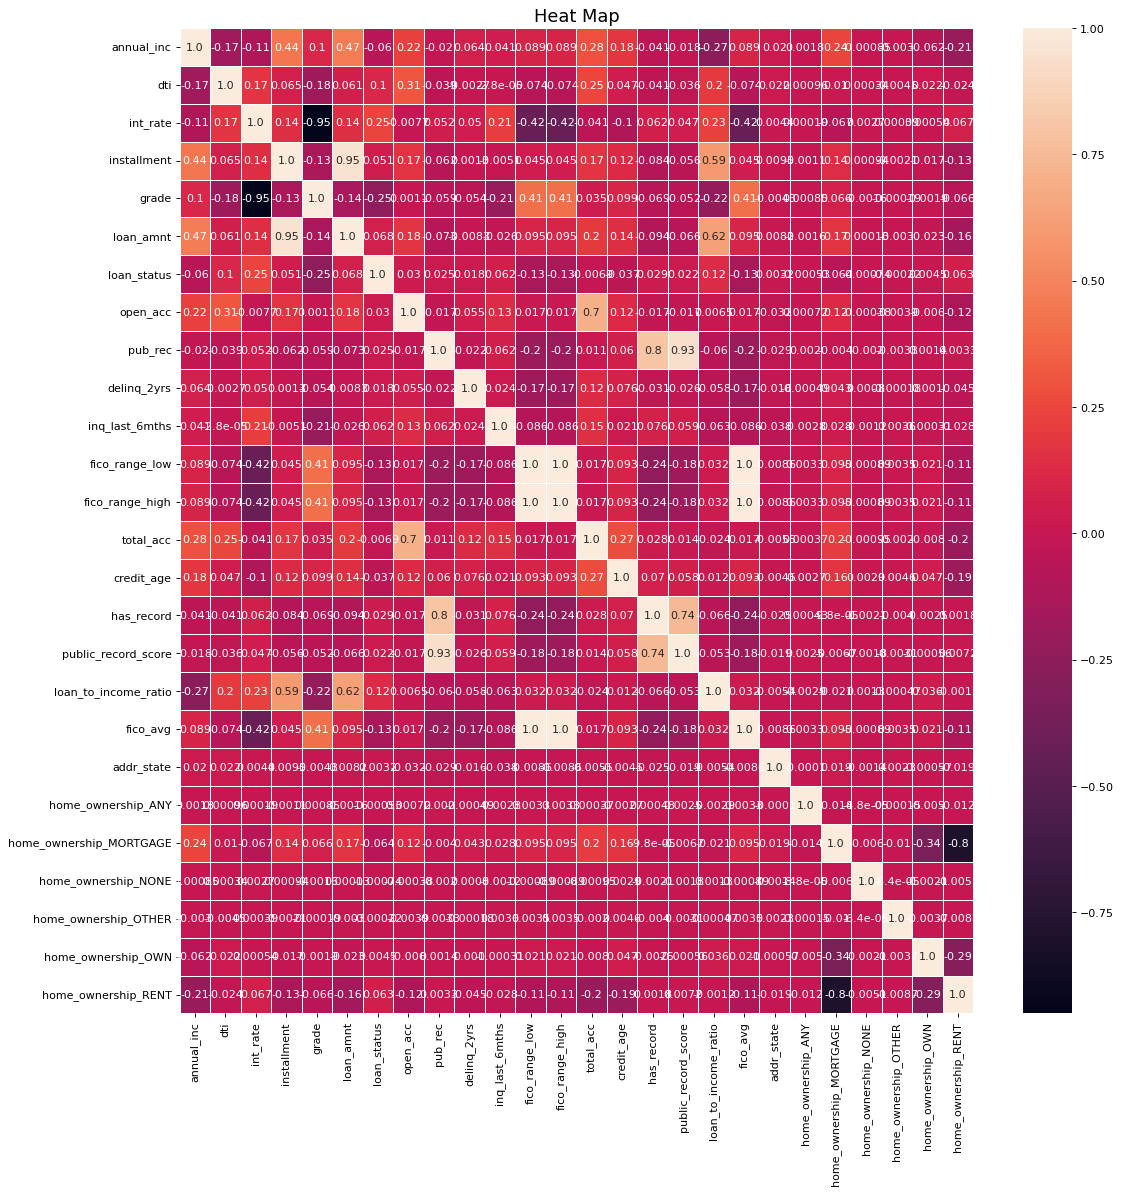

In [95]:
#Represent the correlation between the numerical variables thougth The heat map
corr = df_final2_no_outliers.corr(numeric_only= True)
plt.figure(figsize=(16,16), dpi= 80)
sns.heatmap(corr, annot=True , fmt=".2" ,linewidths=.9)
plt.title('Heat Map', fontsize=16)

<Axes: xlabel='loan_amnt', ylabel='annual_inc'>

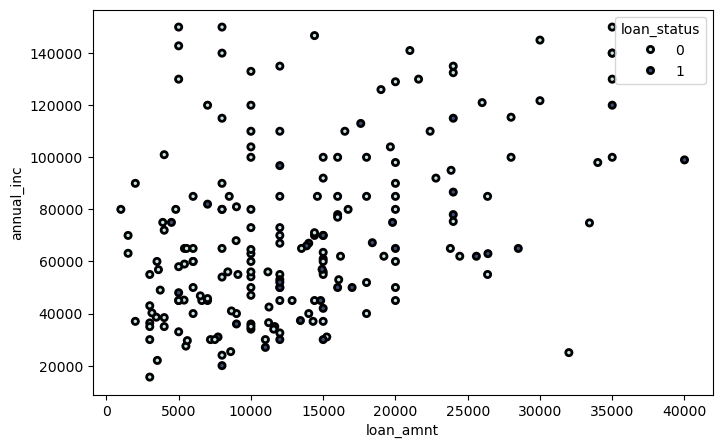

In [97]:
#Scatter plot between 'loan_amnt' (loan amount) and 'annual_inc' (annual income)
sample = df_final2_no_outliers.sample(n = 200, random_state = 42)
plt.figure(figsize=(8,5))
sns.scatterplot(x='loan_amnt', y='annual_inc', palette="ch:r=-.2 , d=.3", hue="loan_status", s = 20, sizes=(10,100), linewidth=2,edgecolor='k',data= sample)

<Axes: xlabel='installment', ylabel='annual_inc'>

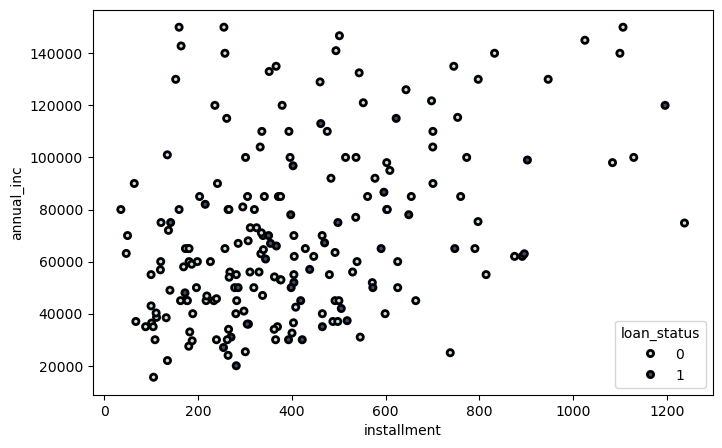

In [99]:
#Scatter plot between 'installment' and 'annual_inc' (annual income)
sample = df_final2_no_outliers.sample(n = 200, random_state = 42)
plt.figure(figsize=(8,5))
sns.scatterplot(x='installment', y='annual_inc', palette="ch:r=-.2 , d=.3", hue="loan_status", s = 20, sizes=(10,100), linewidth=2,edgecolor='k',data= sample)

<Axes: xlabel='fico_range_low', ylabel='int_rate'>

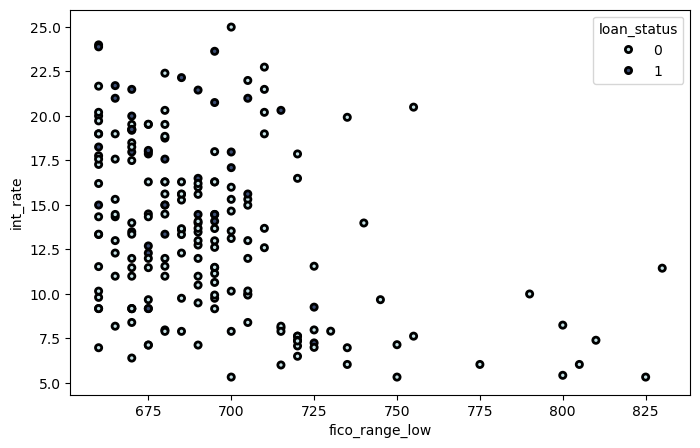

In [101]:
#Scatter plot between 'fico_range_low' and 'int_rate' (interest rate)
sample = df_final2_no_outliers.sample(n = 200, random_state = 30)
plt.figure(figsize=(8,5))
sns.scatterplot(x='fico_range_low', y='int_rate', palette="ch:r=-.2 , d=.3", hue="loan_status", s = 20, sizes=(10,100), linewidth=2,edgecolor='k',data= sample)

In [103]:
#Delete columns in which the items have variance equal to zero
X = X.loc[:, X.var() != 0.0]
print(X.shape)

(1222692, 20)


In [105]:
#Normalization of the two datasets
mm_scaler = preprocessing.MinMaxScaler()
data_scaled = pd.DataFrame(mm_scaler.fit_transform(df_final2_no_outliers),columns = df_final2_no_outliers.columns)

In [107]:
#Split the dataset in X and y
data = data_scaled.copy()
X = data.drop('loan_status' , axis = 1)
y = data['loan_status']
print(y.value_counts())
print(X.shape)

#Split the dataset in X and y
data_pre_sample = data_scaled.copy()
data_sample = data_pre_sample.sample(n = 1000000, random_state = 42)
X_sample = data_sample.drop('loan_status' , axis = 1)
y_sample = data_sample['loan_status']
print(y_sample.value_counts())

loan_status
0.0    1004202
1.0     245892
Name: count, dtype: int64
(1250094, 25)
loan_status
0.0    798
1.0    202
Name: count, dtype: int64


### Unsupervised ML model

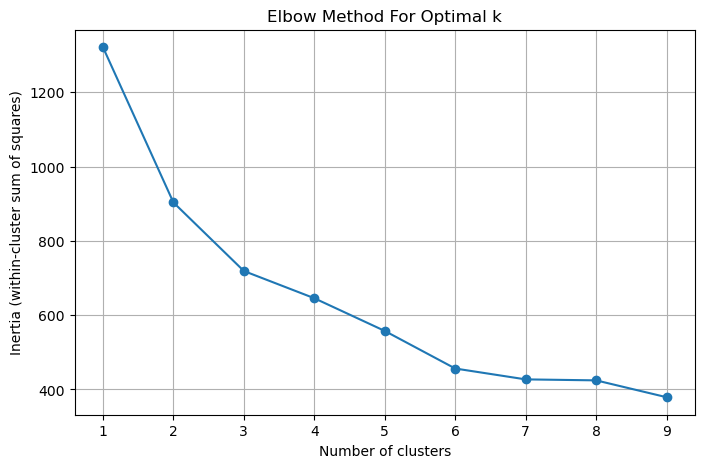

In [109]:
#Clustering
#Computation inertia
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_sample)
    inertia.append(km.inertia_)

#Plotting inertia with Elbow Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.grid(True)
plt.show()

In [111]:
#Use KMeans
nclusters = 2
km = KMeans(n_clusters=nclusters, random_state=42)
km.fit(X_sample)

#Compute the silouette score to evaluate the coerence of the clustering process
sil_score = silhouette_score(X_sample, km.labels_)
print(f"Silhouette Score (k={nclusters}): {sil_score:.4f}")

Silhouette Score (k=2): 0.3142


In [113]:
#Add the cluster to the original dataframe of regressors
X_sample['cluster'] = km.labels_

In [115]:
#Statistical summary of the clustering process
cluster_summary = X_sample.groupby('cluster').mean(numeric_only=True)
print("\n Cluster summary (medie per cluster):")
print(cluster_summary)


 Cluster summary (medie per cluster):
         annual_inc       dti  int_rate  installment     grade  loan_amnt  \
cluster                                                                     
0          0.483322  0.447537  0.376454     0.295025  0.725362   0.386809   
1          0.399519  0.434543  0.406461     0.242167  0.697222   0.304365   

         open_acc   pub_rec  delinq_2yrs  inq_last_6mths  fico_range_low  \
cluster                                                                    
0        0.139783  0.002679     0.007023        0.094293        0.343478   
1        0.124033  0.002562     0.006220        0.081250        0.306439   

         fico_range_high  total_acc  credit_age  has_record  \
cluster                                                       
0               0.341924   0.150325    0.217391    0.180435   
1               0.305053   0.121818    0.190878    0.183333   

         public_record_score  loan_to_income_ratio  fico_avg  addr_state  \
cluster           

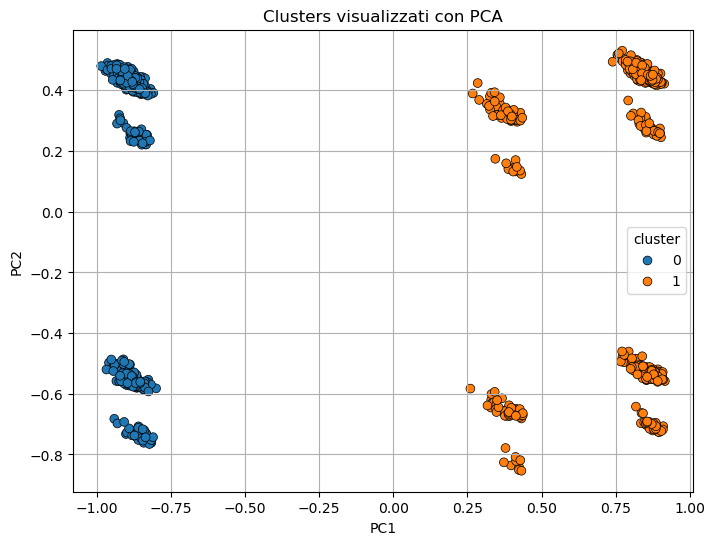

In [117]:
#Grafical rapresentation with PCA
pca = PCA(n_components=2)
X_sample_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(X_sample_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = km.labels_

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=40, edgecolor='k')
plt.title('Clusters visualizzati con PCA')
plt.grid(True)
plt.show()

In [119]:
#Drop meaningless columns
X_sample = X_sample.drop(['home_ownership_OTHER','home_ownership_NONE', 'cluster'], axis = 1)

In [121]:
#Use SMOTE function for balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_sample, y_sample)

In [123]:
#Split the dataset in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())

#Split the dataset in train and test
X_train_o_sample, X_test_sample, y_train_o_sample, y_test_sample = train_test_split(X_resampled, y_resampled, test_size=0.20)
print(X_train_o_sample.shape)
print(X_test_sample.shape)
print(y_train_o_sample.value_counts())

(1000075, 25)
(250019, 25)
loan_status
0.0    803129
1.0    196946
Name: count, dtype: int64
(1276, 23)
(320, 23)
loan_status
0.0    639
1.0    637
Name: count, dtype: int64


### Supervised ML models

In [125]:
#Use a nice function to read simple the visualization of the rwsults of machine learning model
def Cls_model_GrdSrch_Tune(model, Data, X, y, params):
    
    clf = GridSearchCV(model, params, scoring ='accuracy', cv = 5)
    clf=clf.fit(X, y)
    
    print("best score is :" , clf.best_score_)
    print("best estimator is :" , clf.best_estimator_)
    print("best Params is :" , clf.best_params_)
    
    return (clf.best_score_)

*****************************************
DecisionTreeClassifier
Best score is: 0.7241176470588236
Best estimator is: DecisionTreeClassifier()
Best Params are: {}
accuracy_score :  0.79375
precision_score :  0.8064516129032258
recall_score :  0.7763975155279503
f1_score :  0.7911392405063291 

Accuracy of DecisionTreeClassifier is:  79.375
Precision of DecisionTreeClassifier is:  80.64516129032258
Recall of DecisionTreeClassifier is:  77.63975155279503
F1 of DecisionTreeClassifier is:  79.11392405063292 

Confusion_Matrix : 
 [[129  30]
 [ 36 125]] 

*****************************************
RandomForestClassifier
Best score is: 0.8205269607843138
Best estimator is: RandomForestClassifier()
Best Params are: {}
accuracy_score :  0.86875
precision_score :  0.8940397350993378
recall_score :  0.8385093167701864
f1_score :  0.8653846153846154 

Accuracy of RandomForestClassifier is:  86.875
Precision of RandomForestClassifier is:  89.40397350993378
Recall of RandomForestClassifier is:  83.8

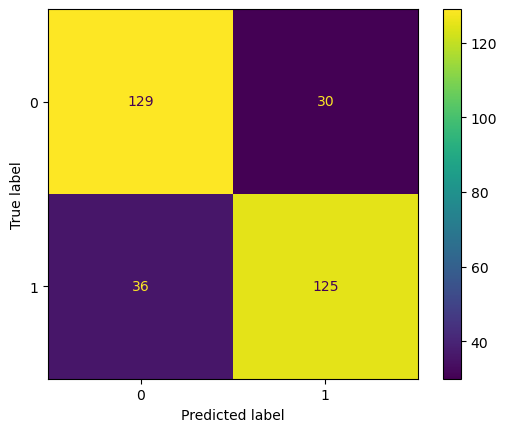

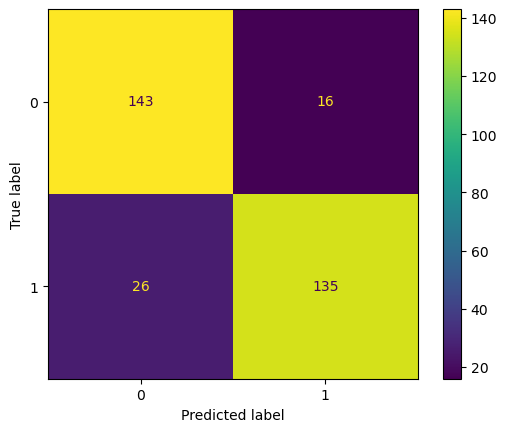

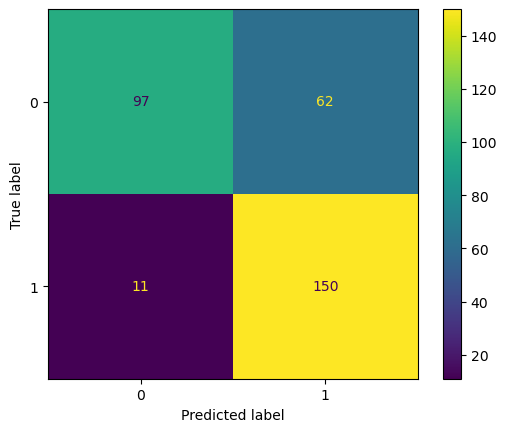

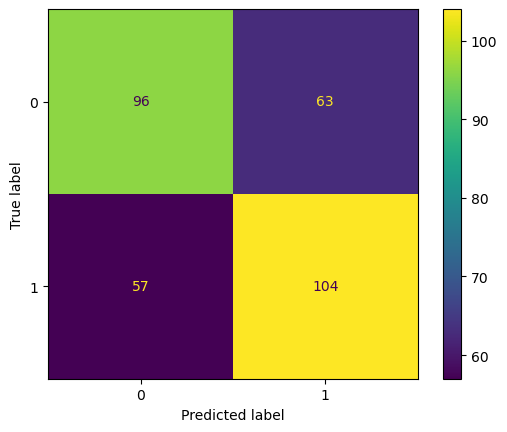

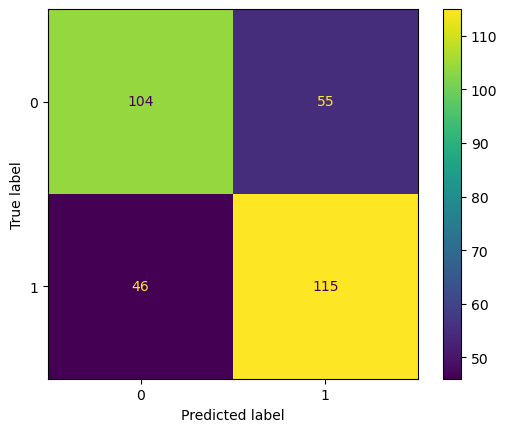

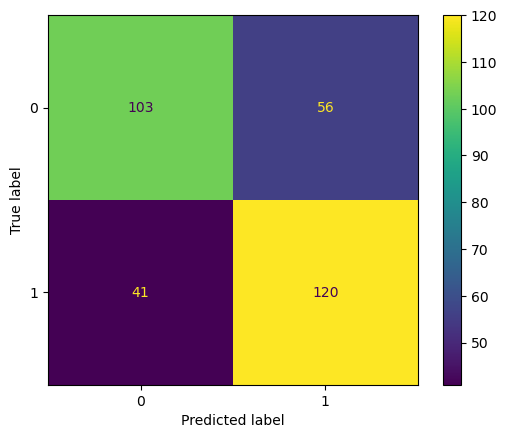

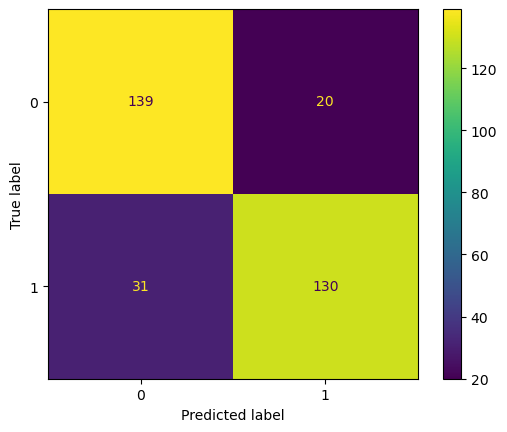

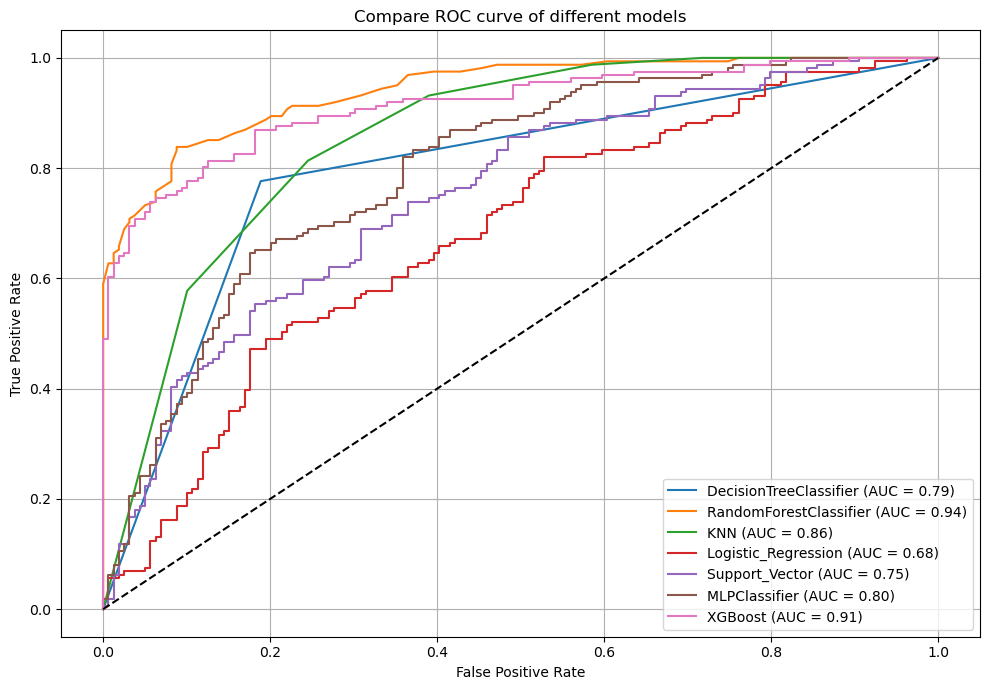

In [127]:
#Run machine learning models
models_lables = ['DecisionTreeClassifier', "RandomForestClassifier", "KNN",
                 "Logistic_Regression","Support_Vector",'MLPClassifier','XGBoost']
models = [DecisionTreeClassifier(), RandomForestClassifier(), 
          knn(),LogisticRegression(penalty = 'l2',C = 1.0, solver = 'liblinear'),
          SVC(probability=True),MLPClassifier(),
          XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)]
Model_Accuracy_default = []

#Parameters
params_DTC = {}
params_RFC = {}
params_KNN = {}
params_LR = {}
params_SVC = {}
params_MLP = {}
params_XGB = {}

params = [params_DTC, params_RFC, params_KNN, params_LR, params_SVC, params_MLP,params_XGB]

#Lists for evaluation
Model_Accuracy_tunned = []
y_predicted_sample_list = []
y_predicted_sample_proba_list = []
roc_auc_list = []
fpr_list = []
tpr_list = []
thresholds_list = []
models_fitted_list = []
clf_best_extimator_list = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for models_lable, model, param in zip(models_lables, models, params):
    print('*****************************************')
    print(models_lable)
    clf = GridSearchCV(model, param, scoring='accuracy', cv=5)
    clf = clf.fit(X_train_o_sample, y_train_o_sample)
    
    print("Best score is:", clf.best_score_)
    print("Best estimator is:", clf.best_estimator_)
    print("Best Params are:", clf.best_params_)
    best_params = clf.best_params_

    #Confusion matrix & classification scores
    y_predicted_sample = clf.predict(X_test_sample)
    y_predicted_sample_proba = clf.predict_proba(X_test_sample)[:, 1]
    conf_matrix = confusion_matrix(y_test_sample, y_predicted_sample)
    acc_score = accuracy_score(y_test_sample, y_predicted_sample)
    pre_score = precision_score(y_test_sample, y_predicted_sample)
    re_score = recall_score(y_test_sample, y_predicted_sample)
    f1_score_ = f1_score(y_test_sample, y_predicted_sample)

    print('accuracy_score : ', acc_score)
    print('precision_score : ', pre_score)
    print('recall_score : ', re_score)
    print('f1_score : ', f1_score_, '\n')
    print(f'Accuracy of {models_lable} is: ', acc_score * 100)
    print(f'Precision of {models_lable} is: ', pre_score * 100)
    print(f'Recall of {models_lable} is: ', re_score * 100)
    print(f'F1 of {models_lable} is: ', f1_score_ * 100, '\n')
    print('Confusion_Matrix : \n', conf_matrix, '\n')
    
    disp = ConfusionMatrixDisplay(conf_matrix)
    disp.plot()

    #ROC-AUC
    roc_auc_val = roc_auc_score(y_test_sample, y_predicted_sample_proba)
    fpr, tpr, thresholds = roc_curve(y_test_sample, y_predicted_sample_proba)

    #Append results
    Model_Accuracy_tunned.append(best_params)
    y_predicted_sample_list.append(y_predicted_sample)
    y_predicted_sample_proba_list.append(y_predicted_sample_proba)
    roc_auc_list.append(roc_auc_val)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    thresholds_list.append(thresholds)
    models_fitted_list.append(clf)
    clf_best_extimator_list.append(clf.best_estimator_)
    accuracy_list.append(acc_score)
    precision_list.append(pre_score)
    recall_list.append(re_score)
    f1_list.append(f1_score_)

#Plot ROC curves
plt.figure(figsize=(10, 7))
for fpr, tpr, label, auc_val in zip(fpr_list, tpr_list, models_lables, roc_auc_list):
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_val:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Compare ROC curve of different models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [129]:
summary_df = pd.DataFrame({
    'Model': models_lables,
    'Accuracy': accuracy_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-score': f1_list
})

summary_df = summary_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
print(summary_df)

                    Model  Accuracy  Precision    Recall  F1-score
0  RandomForestClassifier  0.868750   0.894040  0.838509  0.865385
1                 XGBoost  0.840625   0.866667  0.807453  0.836013
2                     KNN  0.771875   0.707547  0.931677  0.804290
3  DecisionTreeClassifier  0.793750   0.806452  0.776398  0.791139
4           MLPClassifier  0.696875   0.681818  0.745342  0.712166
5          Support_Vector  0.684375   0.676471  0.714286  0.694864
6     Logistic_Regression  0.625000   0.622754  0.645963  0.634146


### Safe AI metrics

*****************************************
DecisionTreeClassifier
                              RGE
grade                    0.500000
int_rate                 0.200782
loan_to_income_ratio     0.102346
loan_amnt                0.089052
dti                      0.086413
open_acc                 0.065200
delinq_2yrs              0.060997
total_acc                0.055914
credit_age               0.049853
annual_inc               0.049462
inq_last_6mths           0.045455
fico_avg                 0.027468
installment              0.025611
fico_range_low           0.018182
fico_range_high          0.016129
has_record               0.009677
public_record_score      0.009482
addr_state               0.009091
home_ownership_MORTGAGE  0.006061
pub_rec                  0.003226
home_ownership_OWN       0.003226
home_ownership_RENT      0.003226
home_ownership_ANY       0.000000


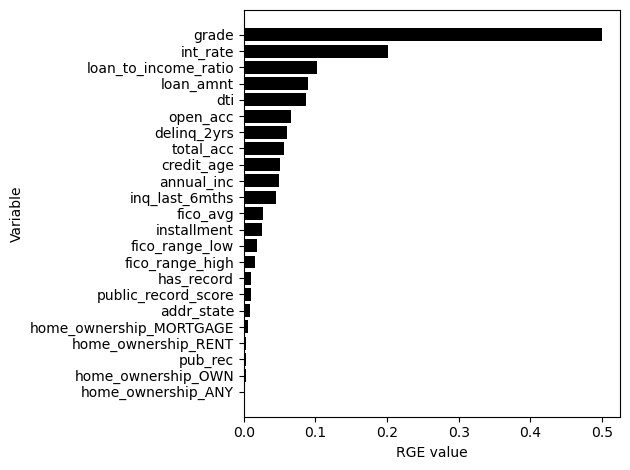

*****************************************
RandomForestClassifier
                              RGE
grade                    0.025754
loan_to_income_ratio     0.019173
int_rate                 0.017615
annual_inc               0.009798
inq_last_6mths           0.009002
dti                      0.008347
installment              0.007270
open_acc                 0.006746
loan_amnt                0.006543
fico_range_low           0.006148
fico_range_high          0.006096
credit_age               0.006087
fico_avg                 0.006006
delinq_2yrs              0.003992
total_acc                0.003764
home_ownership_OWN       0.001327
home_ownership_RENT      0.001298
home_ownership_MORTGAGE  0.001053
addr_state               0.001016
public_record_score      0.000708
pub_rec                  0.000596
has_record               0.000380
home_ownership_ANY       0.000000


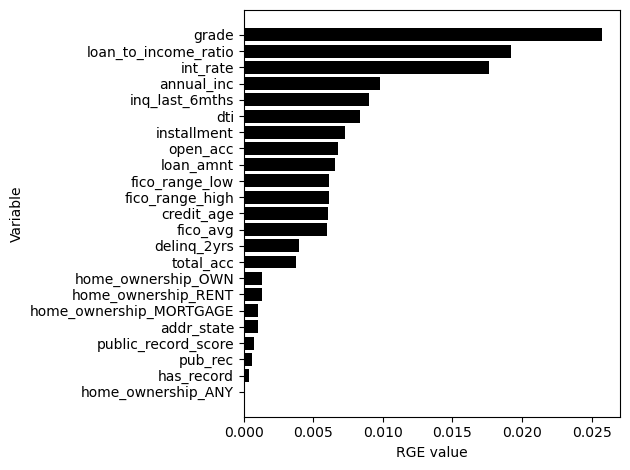

*****************************************
KNN
                              RGE
addr_state               0.121618
annual_inc               0.076819
loan_amnt                0.067860
dti                      0.064446
int_rate                 0.058118
grade                    0.056032
has_record               0.049120
installment              0.040503
inq_last_6mths           0.028641
credit_age               0.017442
fico_avg                 0.016689
fico_range_high          0.016689
fico_range_low           0.016689
total_acc                0.008424
open_acc                 0.005897
home_ownership_OWN       0.001036
loan_to_income_ratio     0.000406
delinq_2yrs              0.000000
public_record_score      0.000000
pub_rec                  0.000000
home_ownership_ANY       0.000000
home_ownership_MORTGAGE  0.000000
home_ownership_RENT      0.000000


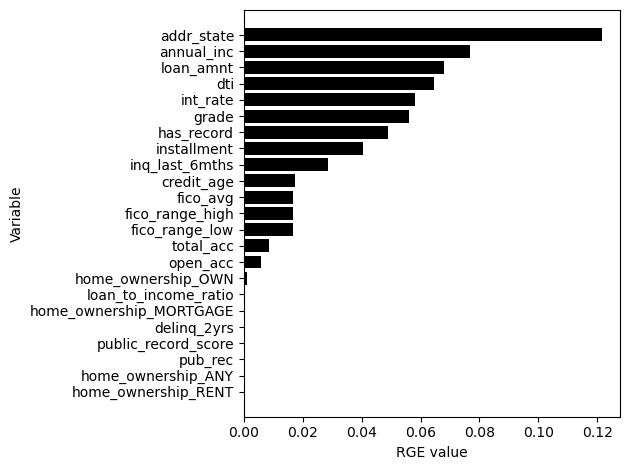

*****************************************
Logistic_Regression
                                  RGE
loan_amnt                7.802467e-02
annual_inc               2.679232e-02
home_ownership_OWN       1.672378e-02
installment              1.612873e-02
dti                      1.078212e-02
home_ownership_RENT      8.085706e-03
grade                    6.537157e-03
int_rate                 6.118167e-03
fico_range_low           4.254711e-03
fico_avg                 4.215067e-03
fico_range_high          4.176062e-03
home_ownership_MORTGAGE  3.990829e-03
credit_age               3.975461e-03
has_record               3.857668e-03
addr_state               2.315024e-03
total_acc                2.017692e-03
open_acc                 3.195746e-04
inq_last_6mths           1.152646e-04
delinq_2yrs              4.449934e-05
pub_rec                  1.110299e-07
public_record_score      7.835579e-08
loan_to_income_ratio     4.728837e-08
home_ownership_ANY       0.000000e+00


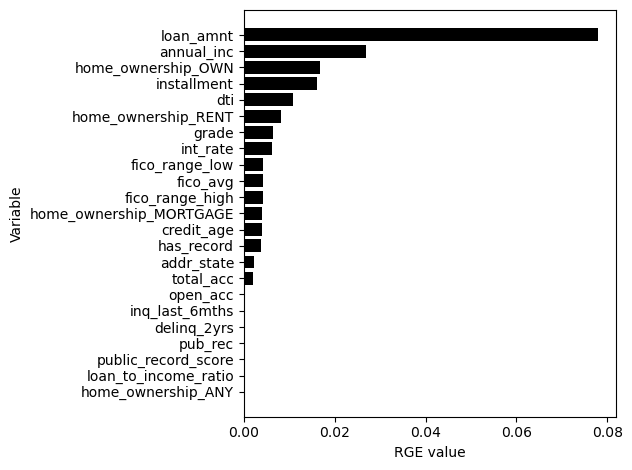

*****************************************
Support_Vector
                                  RGE
loan_amnt                3.968494e-02
addr_state               2.573052e-02
home_ownership_MORTGAGE  2.350584e-02
grade                    1.943783e-02
has_record               1.643556e-02
home_ownership_RENT      1.573377e-02
annual_inc               1.550611e-02
dti                      9.858404e-03
installment              7.512281e-03
int_rate                 6.045350e-03
home_ownership_OWN       2.763269e-03
inq_last_6mths           2.652551e-03
fico_range_low           2.039494e-03
fico_avg                 2.018568e-03
fico_range_high          2.001088e-03
credit_age               1.568356e-03
total_acc                6.911334e-04
open_acc                 1.914506e-04
delinq_2yrs              4.866489e-05
pub_rec                  8.713102e-08
public_record_score      8.185386e-08
loan_to_income_ratio     6.855130e-09
home_ownership_ANY       0.000000e+00


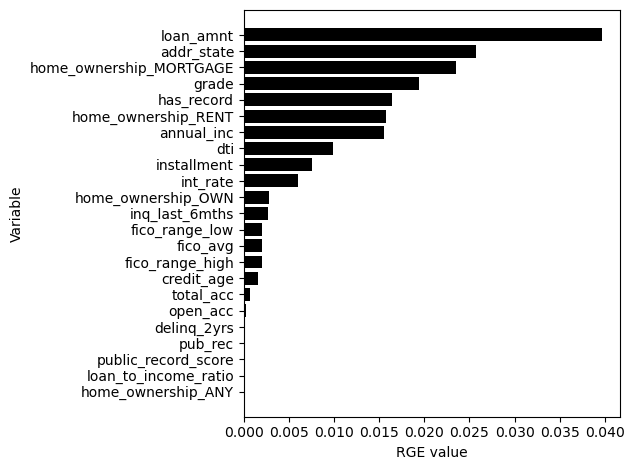

*****************************************
MLPClassifier
                                  RGE
loan_amnt                8.394857e-02
home_ownership_OWN       3.912207e-02
home_ownership_RENT      3.035984e-02
installment              2.786679e-02
annual_inc               2.593973e-02
int_rate                 2.352904e-02
addr_state               2.036608e-02
has_record               1.935647e-02
home_ownership_MORTGAGE  1.683727e-02
dti                      1.580594e-02
total_acc                9.472748e-03
inq_last_6mths           7.536420e-03
grade                    5.663053e-03
open_acc                 4.745283e-03
fico_range_high          4.003943e-03
credit_age               3.630040e-03
delinq_2yrs              3.062791e-03
fico_avg                 1.971305e-03
fico_range_low           1.618176e-03
pub_rec                  2.144332e-04
public_record_score      1.751629e-04
loan_to_income_ratio     1.049756e-04
home_ownership_ANY       3.366664e-08


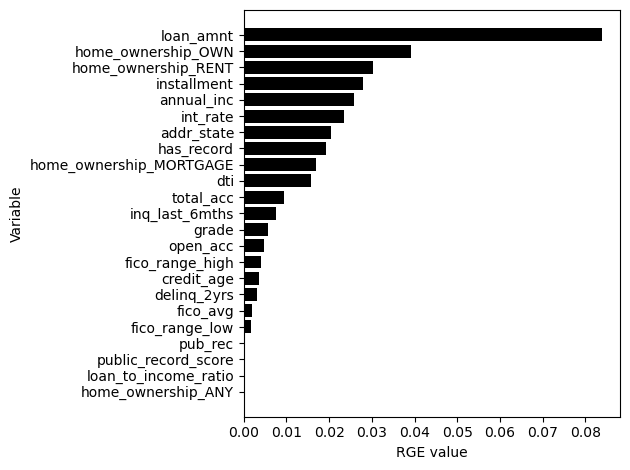

*****************************************
XGBoost
                              RGE
grade                    0.022102
open_acc                 0.017441
loan_to_income_ratio     0.016396
inq_last_6mths           0.015896
fico_range_low           0.014492
dti                      0.012033
annual_inc               0.010222
int_rate                 0.008677
total_acc                0.007009
credit_age               0.006193
installment              0.004917
delinq_2yrs              0.004270
loan_amnt                0.004196
addr_state               0.001154
home_ownership_MORTGAGE  0.001144
public_record_score      0.000792
home_ownership_RENT      0.000691
pub_rec                  0.000360
home_ownership_OWN       0.000247
fico_avg                 0.000000
has_record               0.000000
home_ownership_ANY       0.000000
fico_range_high          0.000000


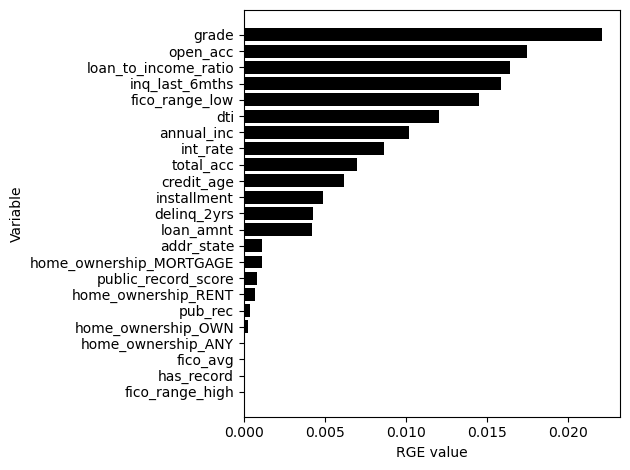

In [131]:
#Explainability for each model
i = 0
for models_lable in models_lables:
    print('*****************************************')
    print(models_lable)
    rge_df = check_explainability.compute_rge_values(X_train_o_sample, X_test_sample, y_predicted_sample_proba_list[i], models_fitted_list[i], list(X_test_sample.columns))
    print(rge_df)
    rge_df.sort_values(by="RGE", ascending= True, inplace= True)
    plt.barh(rge_df.index, rge_df["RGE"], color= "black")
    plt.xlabel("RGE value")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()
    i += 1

In [133]:
#Robustness for each model
i = 0
for models_lable in models_lables:
    print('*****************************************')
    print(models_lable)
    rgr = check_robustness.compute_rgr_values(X_test_sample, y_predicted_sample_proba_list[i], models_fitted_list[i], list(X_test_sample.columns))
    print(rgr)
    i += 1

*****************************************
DecisionTreeClassifier
                              RGR
delinq_2yrs              1.000000
home_ownership_OWN       1.000000
home_ownership_MORTGAGE  1.000000
home_ownership_ANY       1.000000
addr_state               1.000000
fico_range_high          0.996970
public_record_score      0.996774
has_record               0.996774
home_ownership_RENT      0.996774
installment              0.996774
pub_rec                  0.993744
fico_range_low           0.990714
total_acc                0.987879
credit_age               0.987488
open_acc                 0.984457
fico_avg                 0.981427
loan_amnt                0.978201
inq_last_6mths           0.978006
annual_inc               0.975367
dti                      0.975171
loan_to_income_ratio     0.965494
int_rate                 0.952786
grade                    0.933431
*****************************************
RandomForestClassifier
                              RGR
home_ownership_ANY  